# Read in gene information 

## Reference based positions

In [73]:
genes_ref_pos = {
    "P_protein": [(2308, 3182), (0, 1625)],
    "L_protein": [(2849, 3182), (0, 837)],
    "M_protein": [(3173, 3182), (0, 837)],
    "S_protein": [(156, 837)],
    "X_protein": [(1375, 1840)],
    "PreCore": [(1815, 2454)],
    "Core": [(1902, 2454)],
}

## Conversion to MSA positions

In [84]:
msa = "../data/filtered/MSA_auto_sub500.fasta"
gb  = "../../ingest/defaults/NC_003977.gb"
out = "../data/map_NC_003977_MSA.tsv"

!python map_gb_position_to_msa.py $msa $gb > $out


In [85]:
import csv

# read mapping: gb_pos -> aln_pos
gb2aln = {}

with open("../data/map_NC_003977_MSA.tsv") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        if not parts[0].isdigit():
            continue  # skip header / metadata lines

        aln_pos = parts[0]
        gb_pos = parts[1]

        if gb_pos.isdigit():
            gb2aln[int(gb_pos)] = int(aln_pos)
# map genes to MSA positions
genes_MSA_pos = {}

for gene, intervals in genes_ref_pos.items():
    msa_positions = []
    for start, end in intervals:
        for gb_pos in range(start + 1, end + 1):  # gb positions are 1-based
            if gb_pos in gb2aln:
                msa_positions.append(gb2aln[gb_pos])
    genes_MSA_pos[gene] = msa_positions


In [86]:
def to_blocks(pos):
    pos = sorted(set(pos))
    if not pos:
        return []
    blocks = []
    s = e = pos[0]
    for p in pos[1:]:
        if p == e + 1:
            e = p
        else:
            blocks.append((s, e))
            s = e = p
    blocks.append((s, e))
    return blocks

gene_msa_blocks = {g: to_blocks(ps) for g, ps in genes_MSA_pos.items()}


In [88]:
gene_msa_blocks

{'P_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 1148),
  (1150, 1176),
  (1178, 1258),
  (1260, 1305),
  (1307, 1374),
  (1376, 1690),
  (2575, 2624),
  (2631, 3122),
  (3124, 3128),
  (3162, 3453),
  (3455, 3488)],
 'L_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 897),
  (3122, 3122),
  (3124, 3128),
  (3162, 3453),
  (3455, 3488)],
 'M_protein': [(42, 54),
  (59, 74),
  (78, 78),
  (85, 890),
  (897, 897),
  (3481, 3488)],
 'S_protein': [(211, 890), (897, 897)],
 'X_protein': [(1441, 1709),
  (1798, 1802),
  (1835, 1945),
  (1947, 2006),
  (2043, 2043),
  (2049, 2067)],
 'PreCore': [(2002, 2006),
  (2043, 2043),
  (2049, 2131),
  (2168, 2214),
  (2216, 2259),
  (2261, 2496),
  (2498, 2624),
  (2631, 2726)],
 'Core': [(2130, 2131),
  (2168, 2214),
  (2216, 2259),
  (2261, 2496),
  (2498, 2624),
  (2631, 2726)]}

# Analyse alignment

### Add gene position plotting

In [159]:
import matplotlib.pyplot as plt

def add_annotation_track(fig, ax, annotations, height_ratio=1):
    """
    annotations: list of (start, end, label)
    """
    gs = ax.get_gridspec()
    ax_track = fig.add_subplot(
        gs.new_subplotspec((1, 0), rowspan=1)
    )

    ax_track.sharex(ax)

    colors = plt.cm.tab10.colors

    n = len(annotations)
    ax_track.set_ylim(0, n)

    for i, (label, blocks) in enumerate(annotations.items()):
        y0 = n - i - 0.8
        color = colors[i % len(colors)]

        # draw all blocks for this gene
        for start, end in blocks:
            width = end - start + 1
            ax_track.broken_barh(
                [(start, width)],
                (y0, 0.6),
                facecolors=color
            )

        # label once, after the last segment

        blocks_sorted = sorted(blocks)  # list of (start,end)
        m = len(blocks_sorted)
        L = int(ax.get_xlim()[1])       # alignment length from the shared x-axis

        # compute gaps to the *next* block, including circular wrap (last -> first)
        gaps = []
        for k in range(m):
            e_k = blocks_sorted[k][1]
            s_next = blocks_sorted[(k + 1) % m][0]
            if k < m - 1:
                gap = s_next - e_k - 1
            else:
                gap = (L - e_k) + (blocks_sorted[0][0] - 1)  # wrap gap
            gaps.append(gap)

        k_max = int(np.argmax(gaps))              # block before largest gap
        end_for_label = blocks_sorted[k_max][1]   # label after this block

        # label once, horizontally aligned with bar, using offset in points
        ax_track.annotate(
            label,
            xy=(end_for_label, y0 + 0.3),
            xytext=(8, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=12,
            color=color
        )


    ax_track.set_yticks([])
    ax_track.set_xlabel("MSA position")


    return ax_track


## Characterise gaps 

### read in alignment

In [101]:
from Bio import AlignIO
import sys

aln = AlignIO.read("../data/filtered/MSA_auto_sub500.fasta", "fasta")

gap_chars = {"-", "."}
print(aln.get_alignment_length())

counts = []
for i in range(aln.get_alignment_length()):
    n = sum(1 for rec in aln if rec.seq[i] not in gap_chars)
    counts.append(n)

nseq = len(aln)
rel = [c / nseq for c in counts]


3491


### non-gap sequences per position

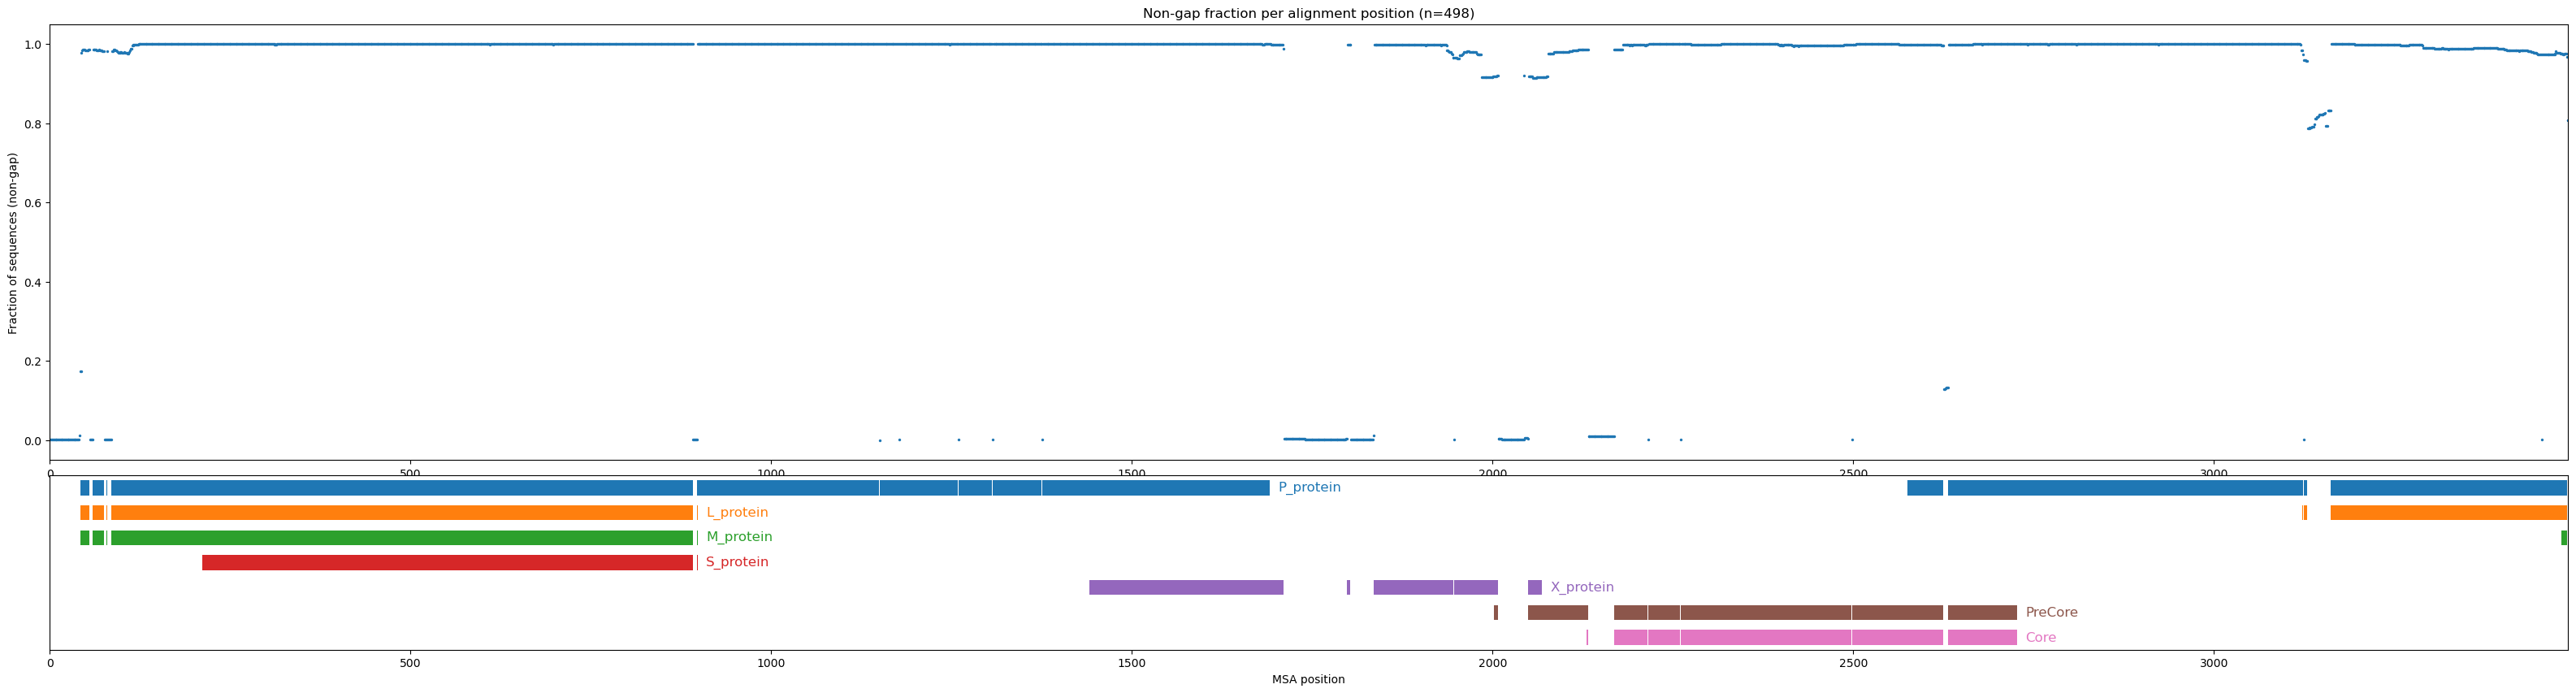

In [102]:
import numpy as np
import matplotlib.pyplot as plt

L = aln.get_alignment_length()
x = np.arange(1, len(rel) + 1)

fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[5, 2], hspace=0.05)
ax = fig.add_subplot(gs[0])

# --- upper plot ---
ax.scatter(x, rel, s=2)
ax.set_title(f"Non-gap fraction per alignment position (n={nseq})")
ax.set_ylabel("Fraction of sequences (non-gap)")
ax.set_xlim(0, L)

ax_track = add_annotation_track(fig, ax, gene_msa_blocks)

plt.show()


### indels per position

In [116]:
def plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks=None, gene=None,
                          plot_ins=True, plot_del=True, figsize=(40, 10),
                          height_ratios=(6, 2), hspace=0.05):
    import numpy as np
    import matplotlib.pyplot as plt

    x = np.arange(1, len(rel) + 1)
    L = aln.get_alignment_length()
    rel_arr = np.asarray(rel)

    ins = np.where(rel_arr < 0.5, rel_arr, np.nan) if plot_ins else None
    del_ = np.where(rel_arr > 0.5, 1 - rel_arr, np.nan) if plot_del else None

    fig, (ax, ax_track) = plt.subplots(
        2, 1, sharex=True, figsize=figsize,
        gridspec_kw={"height_ratios": list(height_ratios), "hspace": hspace}
    )
    ax.tick_params(axis="x", labelbottom=True)

    if plot_ins:
        ax.scatter(x, ins, s=8, c="tab:blue",
                   label="insertions (<50% non-gap)")
    if plot_del:
        ax.scatter(x, del_, s=8, c="tab:orange",
                   label="deletions (gap fraction, >50% non-gap)")

    ax.set_ylabel("Percentage of sequences", fontsize=20)
    ax.set_title(f"Insertion/Deletion score per position (n={nseq})")
    ax.legend(markerscale=5, frameon=False, fontsize=20)

    if gene_msa_blocks is not None:
        add_annotation_track(fig, ax, gene_msa_blocks)

    # optional zoom to one gene span
    if gene is not None and gene_msa_blocks is not None:
        blocks = gene_msa_blocks[gene]
        xmin = min(s for s, e in blocks)
        xmax = max(e for s, e in blocks)
        pad = int(0.02 * (xmax - xmin + 1)) + 5
        ax.set_xlim(max(0, xmin - pad), min(L, xmax + pad))
    else:
        ax.set_xlim(0, L)

    plt.show()
    return fig, ax, ax_track


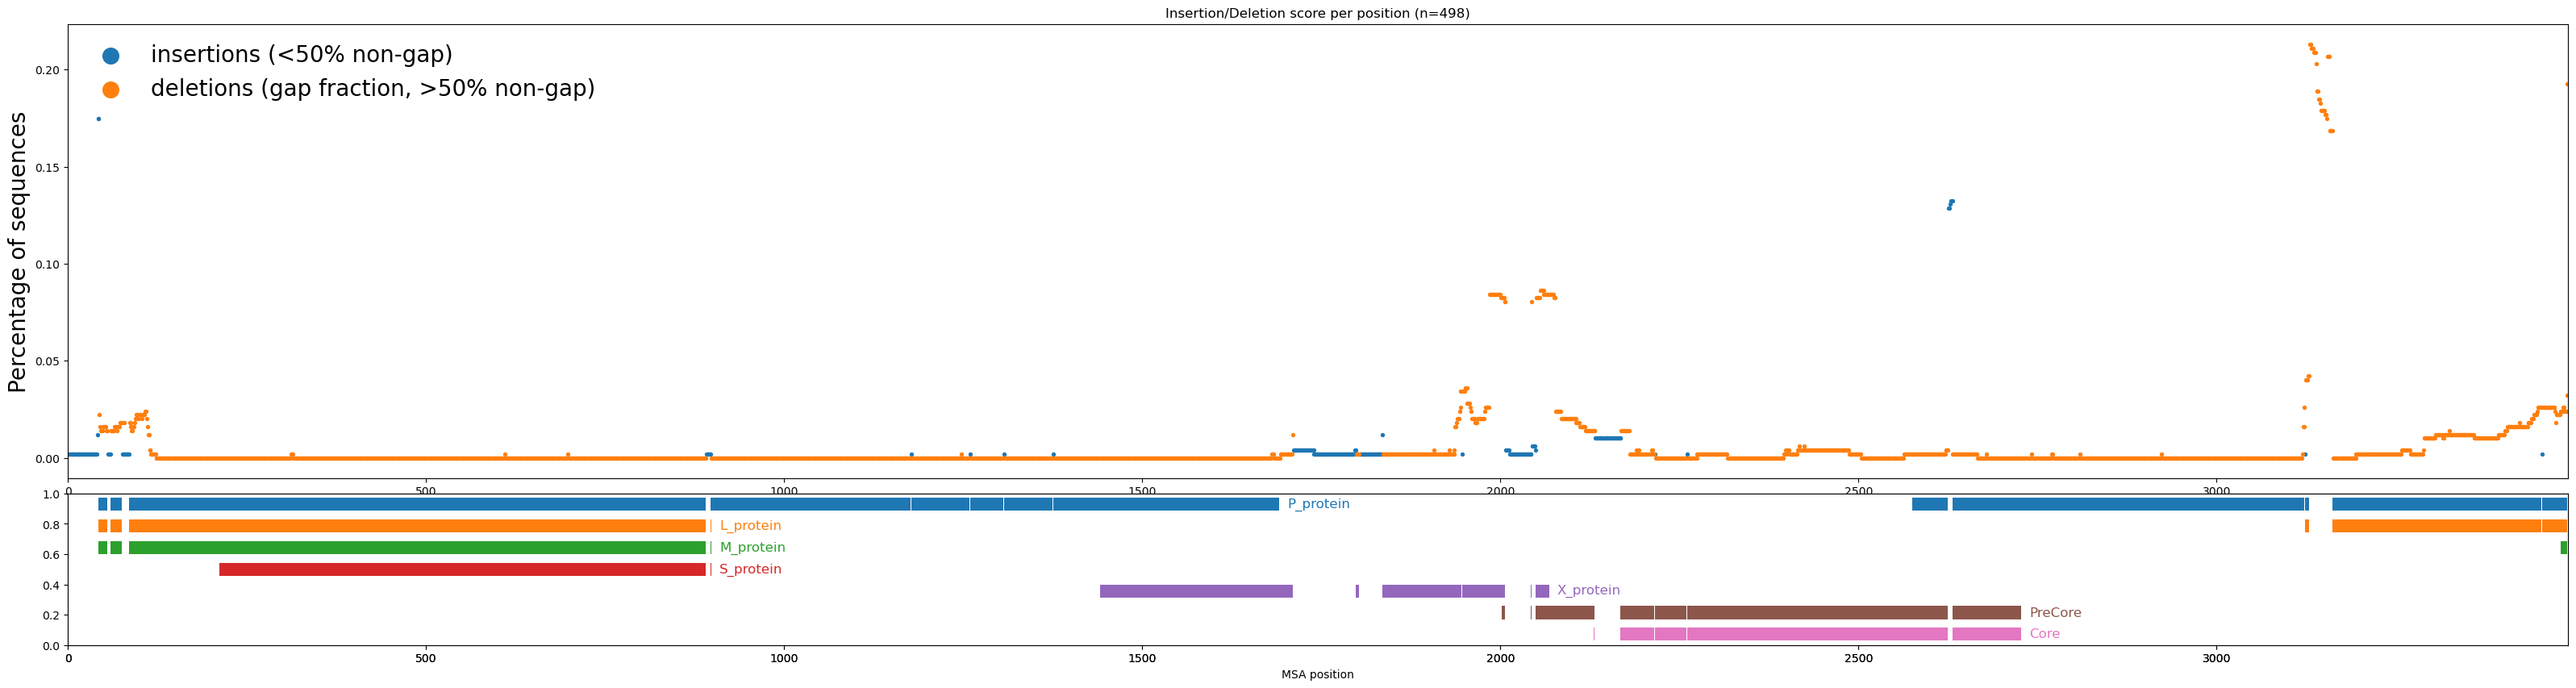

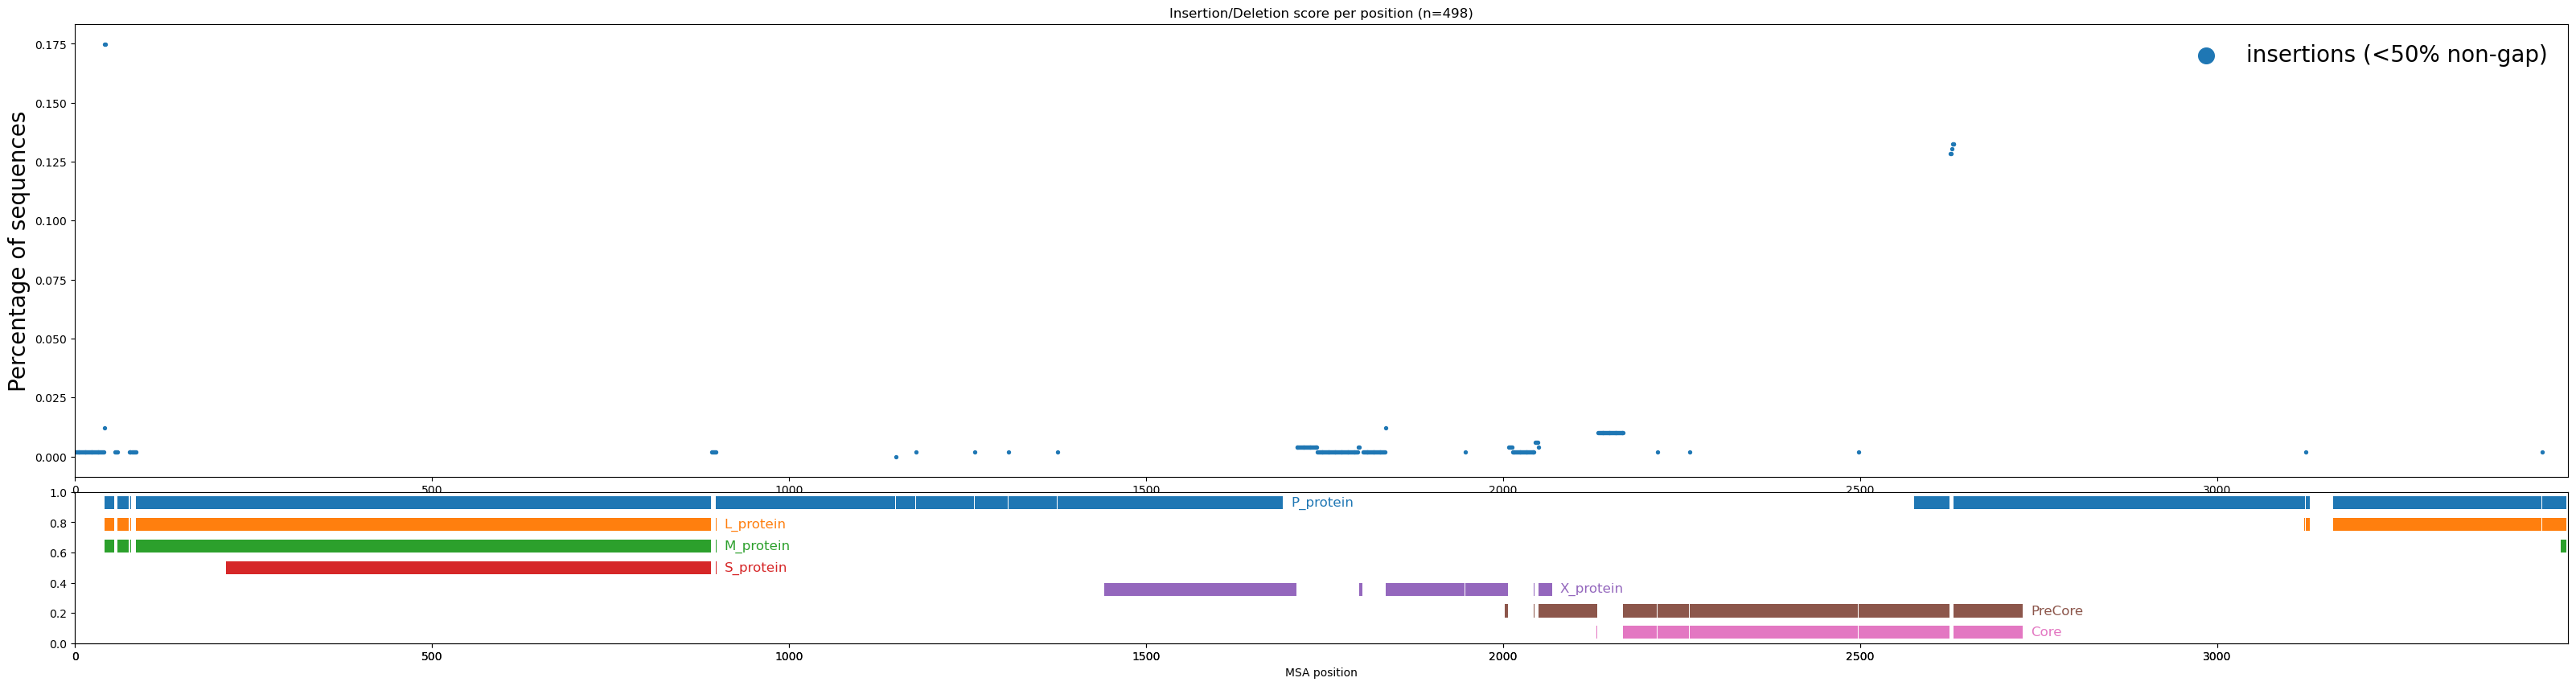

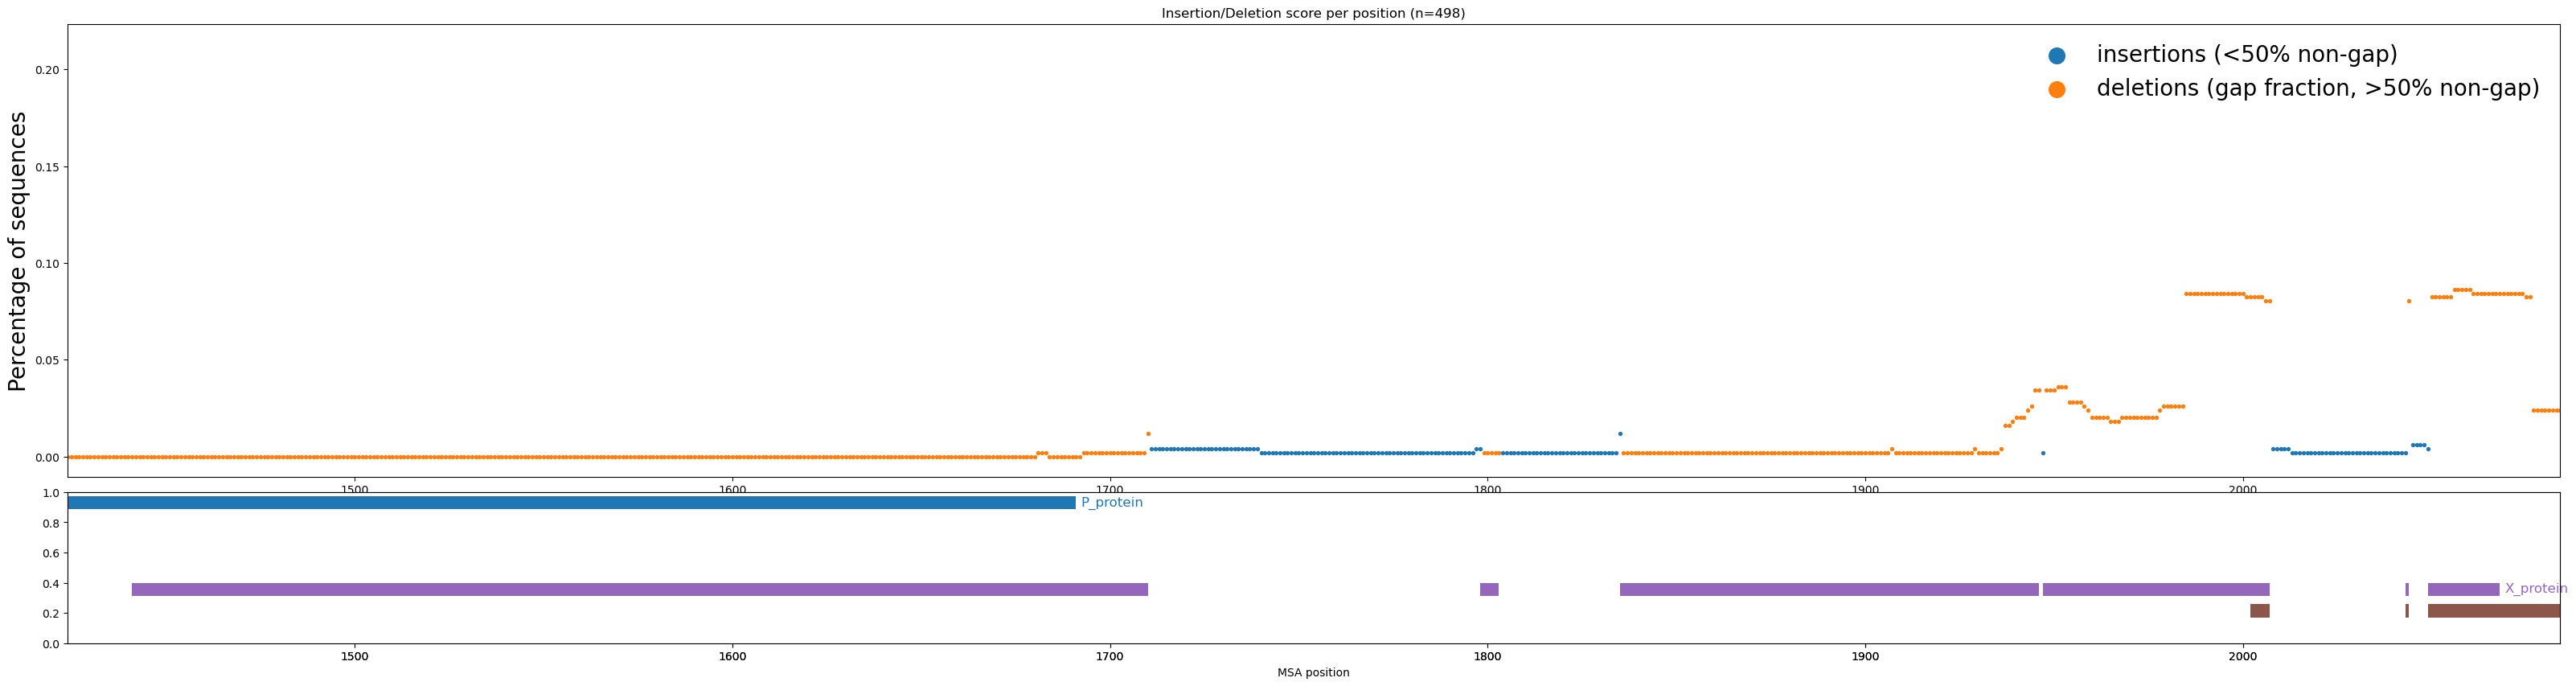

(<Figure size 4000x1000 with 3 Axes>,
 <Axes: title={'center': 'Insertion/Deletion score per position (n=498)'}, ylabel='Percentage of sequences'>,
 <Axes: >)

In [118]:
# both
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks)

# only deletions
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks, plot_del=False)

# zoom to one gene
plot_indel_with_genes(rel, aln, nseq, gene_msa_blocks, gene="X_protein")


In [119]:
gap_chars = {"-", "."}

def gap_intervals_for_alignment(aln):
    """
    Returns: dict {seq_id: [(gap_start, gap_end), ...]}
    Positions are 1-based, inclusive.
    Circular merge: if a gap touches the end and start, it becomes one interval with gap_end < gap_start.
    """
    L = aln.get_alignment_length()
    gaps = {}

    for rec in aln:
        s = str(rec.seq)
        runs = []

        in_gap = False
        start = None

        for i, c in enumerate(s):
            is_gap = c in gap_chars
            if is_gap and not in_gap:
                in_gap = True
                start = i
            elif not is_gap and in_gap:
                runs.append((start, i - 1))
                in_gap = False

        if in_gap:
            runs.append((start, L - 1))

        # merge end-gap with start-gap (circular)
        if runs and runs[0][0] == 0 and runs[-1][1] == L - 1 and len(runs) >= 2:
            merged = (runs[-1][0], runs[0][1])   # end < start indicates wrap
            runs = [merged] + runs[1:-1]

        # convert to 1-based inclusive
        gaps[rec.id] = [(a + 1, b + 1) for a, b in runs]

    return gaps

gaps_by_seq = gap_intervals_for_alignment(aln)


### Gaps and unique gaps

In [154]:
gaps_by_seq

{'NC_003977': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
  (2261, 2261),
  (2498, 2498),
  (2626, 2631),
  (3124, 3124),
  (3130, 3162),
  (3455, 3455)],
 'PQ256967': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
  (2261, 2261),
  (2498, 2498),
  (2626, 2631),
  (3124, 3124),
  (3130, 3162),
  (3455, 3455)],
 'PQ256969': [(3490, 41),
  (56, 59),
  (76, 78),
  (80, 85),
  (892, 897),
  (1150, 1150),
  (1178, 1178),
  (1260, 1260),
  (1307, 1307),
  (1376, 1376),
  (1711, 1798),
  (1804, 1835),
  (1947, 1947),
  (2008, 2043),
  (2045, 2049),
  (2133, 2168),
  (2216, 2216),
 

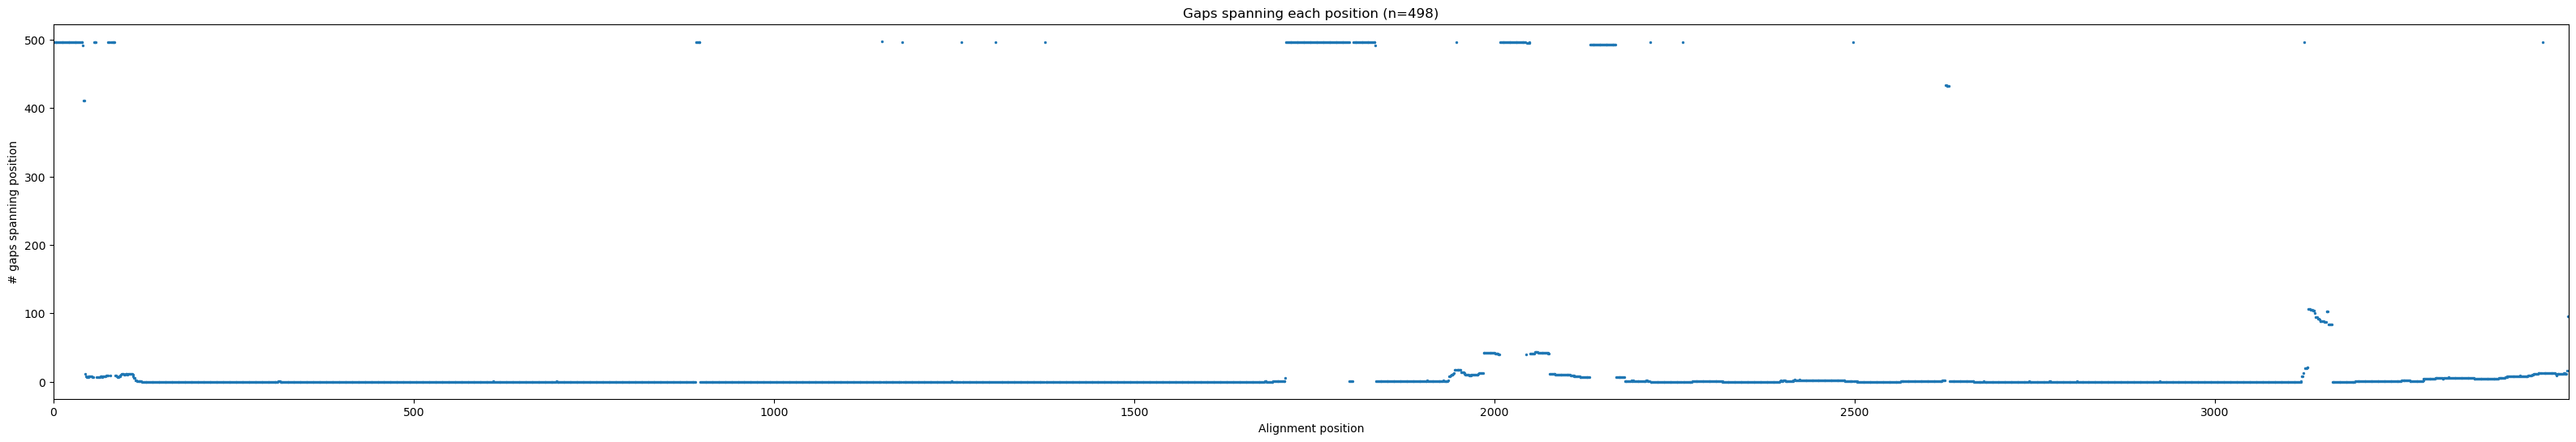

In [121]:
L = aln.get_alignment_length()
gap_counts = np.zeros(L, dtype=int)

for intervals in gaps_by_seq.values():
    for s, e in intervals:
        if e >= s:
            gap_counts[s-1:e] += 1
        else:
            # wrapped gap: s..L and 1..e
            gap_counts[s-1:L] += 1
            gap_counts[0:e] += 1

x = np.arange(1, L + 1)
plt.figure(figsize=(40, 6))
plt.scatter(x, gap_counts, s=2)
plt.xlim(0, L)
plt.xlabel("Alignment position")
plt.ylabel("# gaps spanning position")
plt.title(f"Gaps spanning each position (n={len(gaps_by_seq)})")
plt.show()


In [ ]:
from collections import Counter

# gaps_by_seq: {seq_id: [(start,end), ...]} from before
unique_gaps = Counter()

for intervals in gaps_by_seq.values():
    # avoid double-counting same gap within one sequence
    for gap in set(intervals):
        unique_gaps[gap] += 1
unique_gaps = dict(unique_gaps)


In [137]:
import matplotlib.colors as mcolors
import numpy as np

def truncate_cmap(cmap, minval=0.0, maxval=0.85, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )

cmap = truncate_cmap(plt.cm.viridis, 0.0, 0.85)


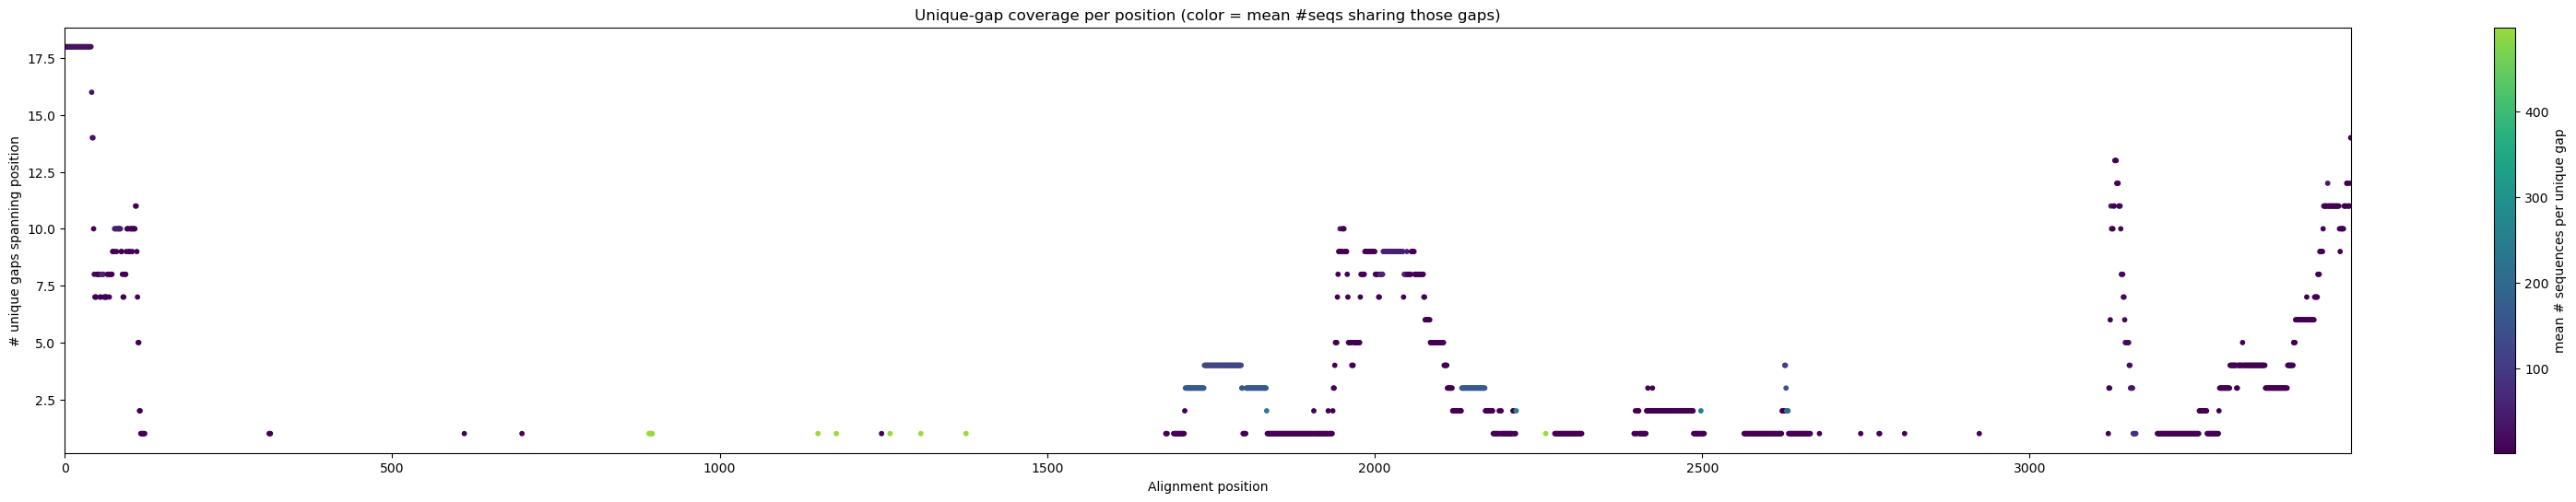

In [138]:
L = aln.get_alignment_length()

# per-position: how many unique gaps cover this position
uniq_count = np.zeros(L, dtype=int)

# per-position: sum of supports (#seqs) of the unique gaps covering this position
support_sum = np.zeros(L, dtype=float)

for (s, e), nshare in unique_gaps.items():
    if e >= s:
        uniq_count[s-1:e] += 1
        support_sum[s-1:e] += nshare
    else:
        # wrapped gap: s..L and 1..e
        uniq_count[s-1:L] += 1
        support_sum[s-1:L] += nshare
        uniq_count[0:e] += 1
        support_sum[0:e] += nshare

# average support of gaps covering each position (NaN where none)
avg_support = np.divide(
    support_sum, uniq_count,
    out=np.full(L, np.nan),
    where=uniq_count > 0
)

from matplotlib.colors import LinearSegmentedColormap


plt.figure(figsize=(40, 6))
sc = plt.scatter(
    x,
    uniq_count,
    s=10,
    c=avg_support,
    cmap=cmap
)

plt.xlim(0, L)
plt.xlabel("Alignment position")
plt.ylabel("# unique gaps spanning position")
plt.title("Unique-gap coverage per position (color = mean #seqs sharing those gaps)")
plt.colorbar(sc, label="mean # sequences per unique gap")
plt.show()


In [126]:
L = aln.get_alignment_length()

xs, ys, cs = [], [], []

# first compute how many unique gaps start/end per position
events_per_pos = np.zeros(L, dtype=int)

for (s, e), nshare in unique_gaps.items():
    # start
    events_per_pos[s-1] += 1
    xs.append(s)
    cs.append(nshare)

    # end
    events_per_pos[e-1] += 1
    xs.append(e)
    cs.append(nshare)

xs = np.array(xs)
cs = np.array(cs)
ys = events_per_pos[xs - 1]


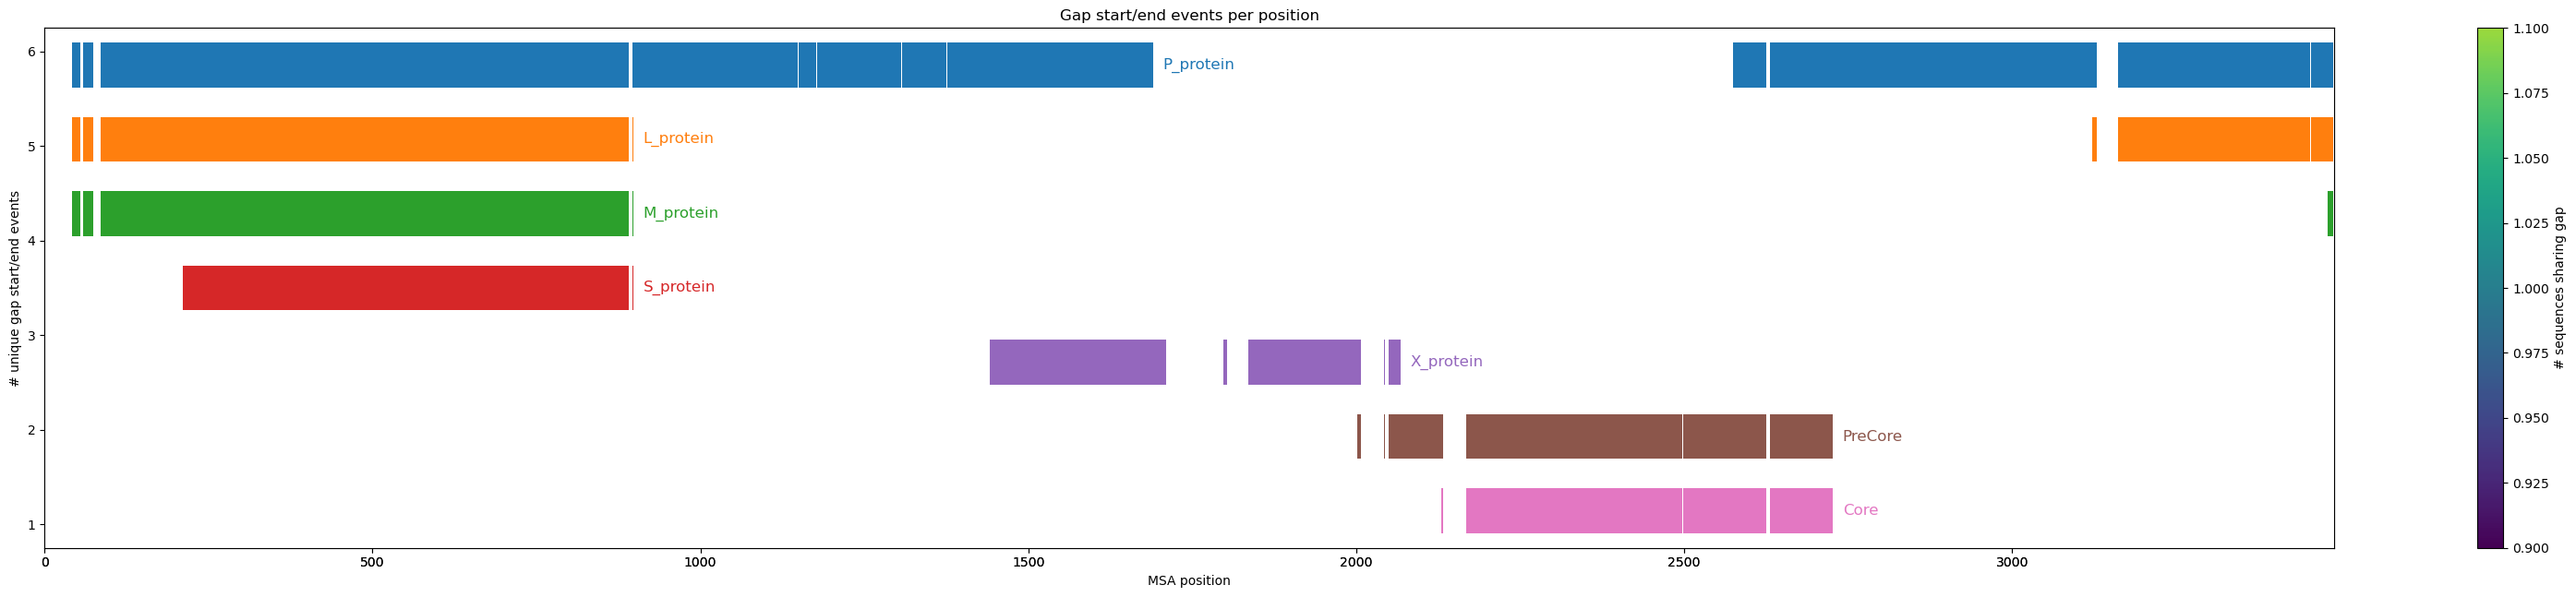

In [160]:
fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[6, 2], hspace=0.05)

ax = fig.add_subplot(gs[0, 0])  # ONLY top axis

m1 = cs == 1
m2 = (cs > 1) & (cs < 450)
m3 = cs >= 450

sc1 = ax.scatter(xs[m1], ys[m1], s=60, c=cs[m1], marker="x", cmap=cmap,
                 label="breakpoint observed in 1 sequence")
ax.scatter(xs[m2], ys[m2], s=60, c=cs[m2], marker="o", cmap=cmap,
           label="indels in multiple sequences")
ax.scatter(xs[m3], ys[m3], s=60, c=cs[m3], marker="s", cmap=cmap,
           label="breakpoints in almost all sequences")

ax.set_xlim(0, L)
ax.set_ylabel("# unique gap start/end events")
ax.set_title("Gap start/end events per position")
ax.legend(frameon=False)

fig.colorbar(sc1, ax=ax, label="# sequences sharing gap")

# function creates the bottom subplot itself
ax_track = add_annotation_track(fig, ax, gene_msa_blocks)

plt.show()


# Stopcodons

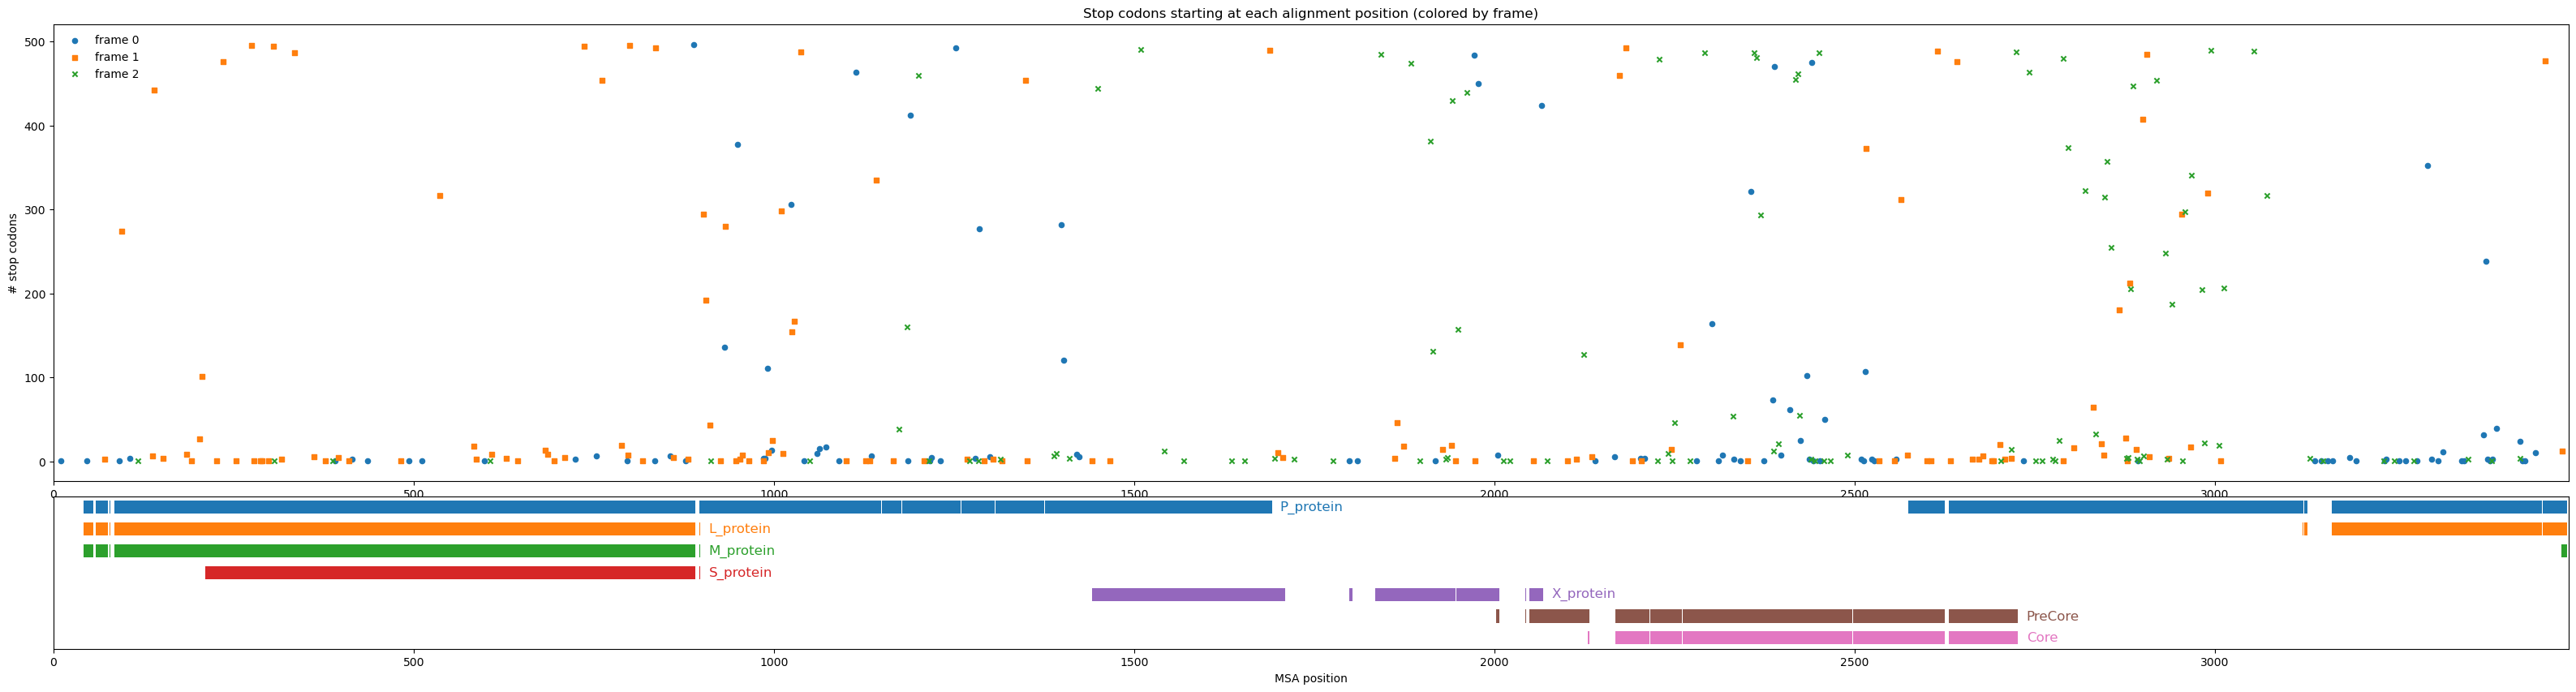

In [161]:
import numpy as np
import matplotlib.pyplot as plt

L = aln.get_alignment_length()
stops = {"TAA", "TAG", "TGA"}

counts_by_frame = np.zeros((3, L), dtype=int)

for rec in aln:
    s = str(rec.seq).upper()
    for i in range(L - 2):
        if s[i:i+3] in stops:
            frame = i % 3
            counts_by_frame[frame, i] += 1

x = np.arange(1, L + 1)

# --- figure + gridspec (ONLY top axis created here) ---
fig = plt.figure(figsize=(40, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[6, 2], hspace=0.05)

ax = fig.add_subplot(gs[0, 0])

# --- top plot ---
markers = ["o", "s", "x"]
colors = ["tab:blue", "tab:orange", "tab:green"]

for frame in range(3):
    m = counts_by_frame[frame] > 0
    ax.scatter(
        x[m],
        counts_by_frame[frame][m],
        s=20,
        marker=markers[frame],
        color=colors[frame],
        label=f"frame {frame}"
    )

ax.set_xlim(0, L)
ax.set_ylabel("# stop codons")
ax.set_title("Stop codons starting at each alignment position (colored by frame)")
ax.legend(frameon=False)

# --- bottom gene annotation track (function unchanged) ---
add_annotation_track(fig, ax, gene_msa_blocks)

plt.show()


 This plot shows me in which frame I am (the one with the least stop codons present!) !?